# Random walks

- Random walks is an important concept in different fields, finance (stock market), physics, math, etc.

- It consists in simulate a sthocastic process by applying random shocks at each period.

- It is a simple and good simulation to illustrate how to use simulations to understand things.

- More intuitvely, we will imagine a drunk man standing on a given position, he will take random steps on the field. After a few steps, will he end up very close to its initial position? or will it manage to to move away?

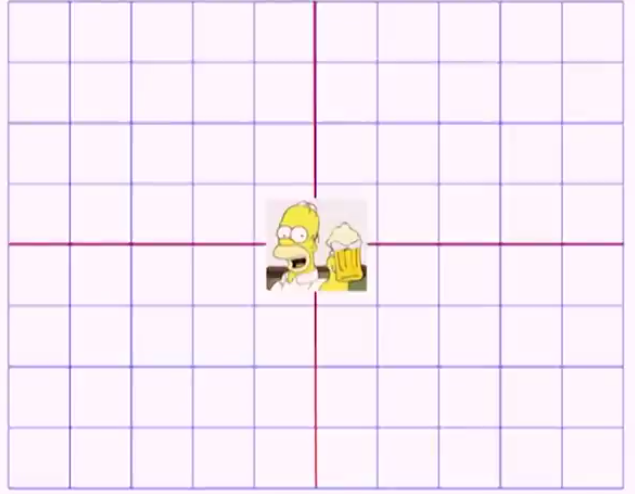

## The Drunkard's walk

- Main question: **Is there an interesting relationship between the number of steps the drunkman takes and how far the drunk is from the origin at the end of those steps?**

- If the drunk takes more steps maybe he will be further from the origin
- Or maybe since this process is random, more or less he never gets very far

In [27]:
import random

In [ ]:
# first we create a Location type in order to set the rules and tools of how the drunk will move
# note how is inmutable, we never change the values, we only return new ones
class Location:
    def __init__(self, x, y):
        """
        x and y are floats
        """

        self.x = x
        self.y = y

    def move(self, deltaX, deltaY):
        """
        deltaX and deltaY are floats
        """

        return Location(self.x + deltaX, self.y + deltaY)

    def getX(self):
        return self.x

    def getY(self):
        return self.y

    def distFrom(self, other):
        """
        'other' is another location class in order to calcualte the distance to it
        """
        xDist = self.x - other.getX()
        yDist = self.y - other.getY()
        return (xDist**2 + yDist**2) ** 0.5

    def __str__(self):
        return "<" + str(self.x) + ", " + str(self.y) + ">"

In [26]:
# we create a base class to be inhertied, it will be use later to to the next sublcasses
class Drunk:
    def __init__(self, name=None):
        """
        Assumes name is a str
        """
        self.name = name

    def __str__(self):
        if self.name != None:
            return self.name
        return "Anonymous"

In [49]:
# we create two types of drunks (two kinds of random walks)


class UsualDrunk(Drunk):
    """
    A drunk that can move randomly to the left, right, up or down
    """

    def takeStep(self):
        stepChoices = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        return random.choice(stepChoices)


class MasochistDrunk(Drunk):
    """
    A drunk that can move randomly, but biased upwards and to the left
    also called a biased random walk
    """

    def takeStep(self):
        stepChoices = [(0.0, 1.1), (0.0, -0.9), (1.0, 0.0), (-1.0, 0.0)]

In [55]:
# we creat the field type, a field will show the location of the drunks
class Field:

    def __init__(self):
        self.drunks = {}

    def addDrunk(self, drunk, loc):
        """
        If a drunk already exists, we raise an error
        If a drunk is not inlcuded, we indlude its name and its location
        """
        if drunk in self.drunks:
            raise ValueError("Duplicate Drunk")
        else:
            self.drunks[drunk] = (
                loc  # improtantt to note that "loc" is an isntance of the location class
            )

    def getLoc(self, drunk):
        if drunk not in self.drunks:
            raise ValueError("Drunk not in field")
        return self.drunks[drunk]

    def moveDrunk(self, drunk):
        """
        Once we have our drunks in their positions we would want see how they move
        Given a 'drunk' we will generate a new random movement and store those coordinates

        """
        if drunk not in self.drunks:
            raise ValueError("Drunk not in field")
        xDist, yDist = drunk.takeStep()

        # we use moveo method of Location to get new location
        # in order to replace the previous stored location with the new location

        self.drunks[drunk] = self.drunks[drunk].move(xDist, yDist)

In [56]:
def walk(f, d, numSteps):
    """
    Creates a walk simulation of the drunk, moving the drunk in numSetps steps
    Assumes: f a field, d a drunk in f, and numSteps an int >= 0
    Returns the dinstance of the final and the initiallocation of the drunk
    """

    start = f.getLoc(d)  # we store the intiail postition
    for s in range(numSteps):
        f.moveDrunk(d)  # we move the position of the drunk n random steps

    return start.distFrom(f.getLoc(d))

In [57]:
def simWalks(numSteps, numTrials, dClass):
    """
    Assumes numSteps an int >= 0, numTrials an int > 0, dClass a subclass of Drunk
    Simulates numTrials walks of numSteps steps each
    Returns a list of the final distances for each trial
    """

    Homer = dClass()
    origin = Location(0, 0)
    distances = []
    for t in range(numTrials):
        f = Field()
        f.addDrunk(Homer, origin)
        distances.append(
            round(walk(f, Homer, numTrials), 1)
        )  # note something interesting here?

    return distances

In [ ]:
def drunkTest(walkLenghts, numTrials, dClass):
    """
    Assumes walkLengths a sequence of ints >= 0
    numTrials an int > 0,
    dClass a subclass of Drunk
    For each number of steps in walkLenghts, runs simWalks with numTrials walks and print Results
    """
    # we simulate different random walks with different number of steps but the same number of trials

    for numSteps in walkLenghts:
        # we will get the list of distances of the simualtion of the respective random walk ntimes
        distances = simWalks(numSteps, numTrials, dClass)

        print(dClass.__name__, "random walk of", numSteps, "steps")

        print(" Mean =", round(sum(distances) / len(distances), 4))

        print(" Max =", max(distances), "Min =", min(distances))

In [62]:
random.seed(0)
drunkTest((10, 100, 1000, 10000), 100, UsualDrunk)

UsualDrunk random walk of 10 steps
 Mean = 8.634
 Max = 21.6 Min = 1.4
UsualDrunk random walk of 100 steps
 Mean = 8.57
 Max = 22.0 Min = 0.0
UsualDrunk random walk of 1000 steps
 Mean = 9.206
 Max = 21.6 Min = 1.4
UsualDrunk random walk of 10000 steps
 Mean = 8.727
 Max = 23.5 Min = 1.4
